# This is to deal only with the ID = 0 File for finding NSC

In [68]:
import numpy as np
import pandas, os, astropy, scipy, math
import matplotlib.pyplot as plt
import sklearn
from photutils.aperture import CircularAperture, SkyCircularAperture, aperture_photometry, EllipticalAperture, SkyEllipticalAperture
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.wcs import WCS
from astropy.visualization import simple_norm
from astropy.wcs.utils import pixel_to_skycoord
import astropy.io.fits as fits
from reproject import reproject_interp
import img_scale
from mpl_toolkits.axes_grid1 import Divider, Size
from astropy.cosmology import FlatLambdaCDM 
from astropy.wcs.utils import proj_plane_pixel_scales

In [69]:
# Writing a function to calculate the magnitude difference bewteen the 2 largest objects
def max_mag_diff(magar):
    lstmag = magar.tolist()
    sortedlstmag = sorted(lstmag)
    magdif1 = sortedlstmag[0] - sortedlstmag[1]
    print(" The magnitude difference between the brightest and 2nd brightest object is {}".format(magdif1))

In [70]:
galcen = pandas.read_csv('/Users/ananthmugundhan/Coding/Research_work/Space_data/HST_cut2/0_SMDG1048131+115807_gal_loc.csv')
galcenx0 = galcen['xc'].values[0]
galceny0 = galcen['yc'].values[0]
cut_cat0 = pandas.read_csv('/Users/ananthmugundhan/Coding/Research_work/Space_data/HST_cut2/0_SMDG1048131+115807_cut_catalog.csv')
cut_cat0.columns

Index(['Unnamed: 0', 'ext', 'chip', 'xc', 'yc', 'chi', 'snr', 'sharpness',
       'roundness', 'pa', 'crowding', 'objtype', 'F606W_count', 'F606W_sky',
       'F606W_count_rate', 'F606W_count_rate_uncer', 'F606W_mag_vega',
       'F606W_mag_ubvri', 'F606W_mag_uncer', 'F606W_chi', 'F606W_snr',
       'F606W_sharpness', 'F606W_roundness', 'F606W_crowding', 'F606W_flag',
       'F814W_count', 'F814W_sky', 'F814W_count_rate',
       'F814W_count_rate_uncer', 'F814W_mag_vega', 'F814W_mag_ubvri',
       'F814W_mag_uncer', 'F814W_chi', 'F814W_snr', 'F814W_sharpness',
       'F814W_roundness', 'F814W_crowding', 'F814W_flag', 'aper_4', 'aper_8',
       'newconcent'],
      dtype='object')

In [71]:
# Define cuts that we are using(comment out this cell to get the original data)
use_cat = cut_cat0

max_mag = 35.  # Maxmum mag (Telescope cut)
snr_thresh = 3.  # For nearby, 5
# crowd_thresh = 0.5 #[mag], Normal cut  
# sharp_thresh = 0.25 #Normal cut  defraction spikes
# round_thresh = 3.  #Weak constraint (elongated)
flag_thresh = np.array([0, 2])
flag_label = np.array(['Good', 'Edge', 'Bad,Sat-pixel', 'Edge+badpixel'])

## Instrumental VEGAMAG magnitude cut
print(f"Total dolphot catalogue length: {len(use_cat)}")
print(f"Require: mag < {max_mag}")
condition = (use_cat.iloc[:,16] < max_mag) & (use_cat.iloc[:,29] < max_mag)
sub_dolcut_cat = use_cat[condition]
print(f"New catalogue length: {len(sub_dolcut_cat)}")

## SNR cut
print(f"Require: S/N > {snr_thresh}.")
condition = (sub_dolcut_cat.iloc[:,20] > snr_thresh) & (sub_dolcut_cat.iloc[:,33] > snr_thresh)
sub_dolcut_cat = sub_dolcut_cat[condition]
print(f"New catalogue length: {len(sub_dolcut_cat)}")

## Object Type cut
print("Remove sources that are not type point-like.")
condition = (sub_dolcut_cat.iloc[:,11] <= 2)
sub_dolcut_cat = sub_dolcut_cat[condition]
print(f"New catalogue length: {len(sub_dolcut_cat)}")

## Photometry quality flag cut
print("Remove sources that have flag= ", flag_thresh, "or", flag_label[flag_thresh])
condition = np.isin(sub_dolcut_cat.iloc[:,24], flag_thresh) & np.isin(sub_dolcut_cat.iloc[:,37], flag_thresh)
sub_dolcut_cat = sub_dolcut_cat[condition]
print(f"New catalogue length: {len(sub_dolcut_cat)}")

cut_cat0 = sub_dolcut_cat 

Total dolphot catalogue length: 96577
Require: mag < 35.0
New catalogue length: 96295
Require: S/N > 3.0.
New catalogue length: 3921
Remove sources that are not type point-like.
New catalogue length: 3770
Remove sources that have flag=  [0 2] or ['Good' 'Bad,Sat-pixel']
New catalogue length: 3727


In [72]:
#creating 2 numpy arrays that hold the xc and yc of each bright object
xcgal0 = cut_cat0['xc'].to_numpy()
ycgal0 = cut_cat0['yc'].to_numpy()
f606mag0 = cut_cat0['F606W_mag_vega'].to_numpy()
f814mag0 = cut_cat0['F814W_mag_vega'].to_numpy()

In [73]:
#calculating the distance from the centre of the galaxy for each bright object
distgal0 = np.sqrt((xcgal0 - galcenx0)**2 + (ycgal0 - galceny0)**2)


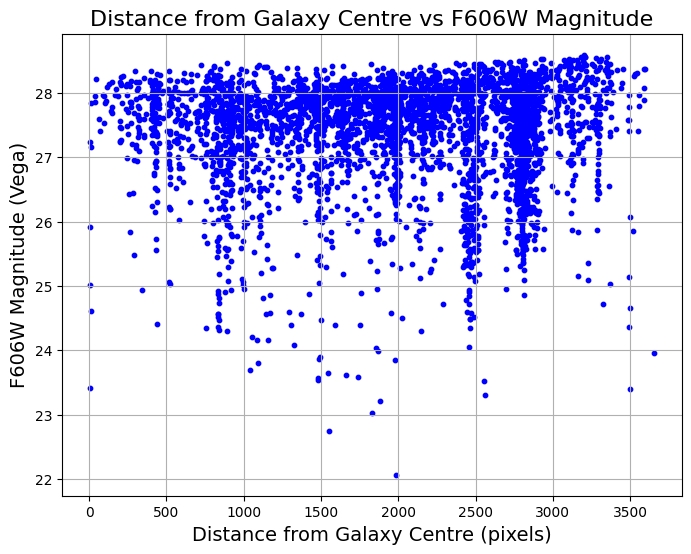

In [74]:
#plotting distance vs magnitude for F606W filter
plt.figure(figsize=(8,6))
plt.scatter(distgal0, f606mag0, color='blue', s=10)
plt.title('Distance from Galaxy Centre vs F606W Magnitude', fontsize=16)
plt.xlabel('Distance from Galaxy Centre (pixels)', fontsize=14)
plt.ylabel('F606W Magnitude (Vega)', fontsize=14)
plt.grid()
plt.show()

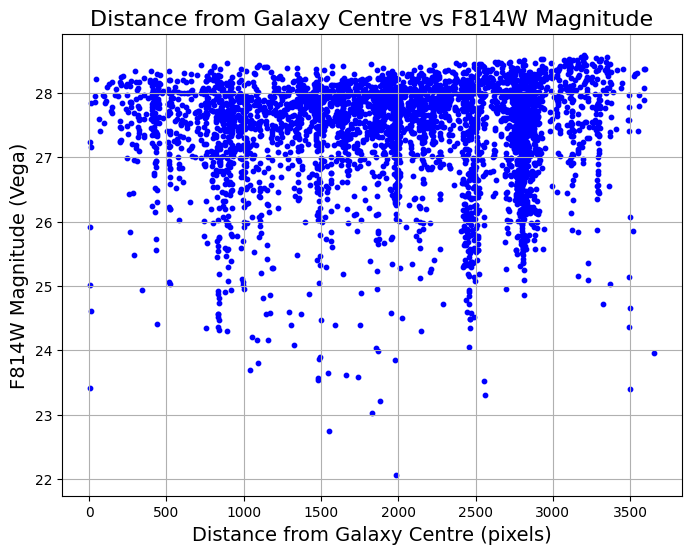

In [75]:
#plotting the distance vs magnitude for F814W filter
plt.figure(figsize=(8,6))
plt.scatter(distgal0, f606mag0, color='blue', s=10)
plt.title('Distance from Galaxy Centre vs F814W Magnitude', fontsize=16)
plt.xlabel('Distance from Galaxy Centre (pixels)', fontsize=14)
plt.ylabel('F814W Magnitude (Vega)', fontsize=14)
plt.grid()
plt.show()

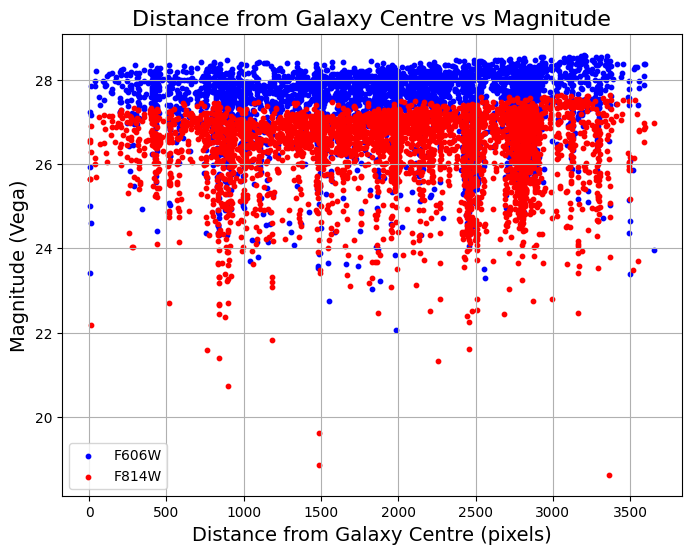

In [76]:
#plotting distance vs magnitude for both filters together
plt.figure(figsize=(8,6))
plt.scatter(distgal0, f606mag0, color='blue', s=10, label='F606W')
plt.scatter(distgal0, f814mag0, color='red', s=10, label='F814W')
plt.title('Distance from Galaxy Centre vs Magnitude', fontsize=16)
plt.xlabel('Distance from Galaxy Centre (pixels)', fontsize=14)
plt.ylabel('Magnitude (Vega)', fontsize=14)
plt.legend()
plt.grid()
plt.show()

In [121]:
# converting pixel in re(arcsec) to pixels
re_arcsec0 = 9.31

hdul0 = fits.open('/Users/ananthmugundhan/Coding/Research_work/Space_data/HST_cut2/ID_0_F814/ID_0_F606/MAST_2026-03-03T2119/HST/jd5h07010_drc.fits')
if len(hdul0) > 1:
    hdr0 = hdul0[1].header
else:
    hdr0 = hdul0[0].header
wcs0 = WCS(hdr0)
pixel_scale_degrees0 = proj_plane_pixel_scales(wcs0)
scale_arcsec_per_pixel0 = pixel_scale_degrees0[0] * 3600
scale_pixel_per_arcsec0 = 1 / scale_arcsec_per_pixel0
re_pixels0 = re_arcsec0 * scale_pixel_per_arcsec0
print(re_pixels0)

186.2000000000002


In [115]:
#refining the bright object list to only include objects within re and finding the colour of the objects
distgal_re0 = distgal0[distgal0 <= re_pixels0]
f606mag_re0 = f606mag0[distgal0 <= re_pixels0]
f814mag_re0 = f814mag0[distgal0 <= re_pixels0]
color0 = f606mag_re0 - f814mag_re0 
colorfull0 = f606mag0 - f814mag0

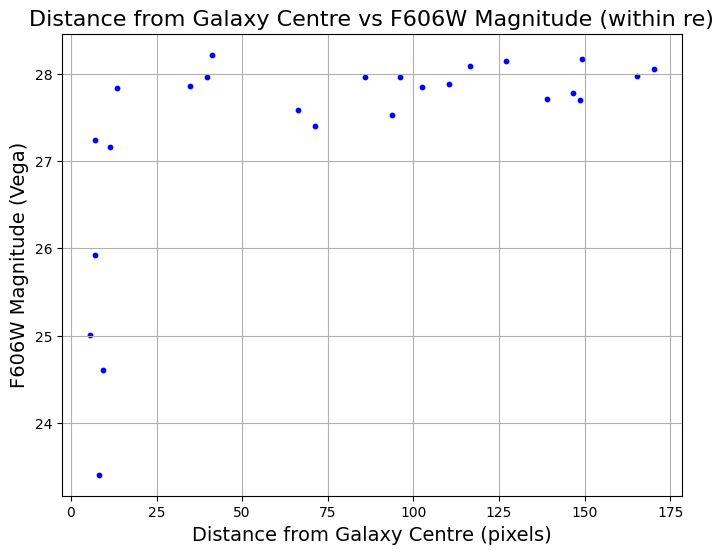

In [79]:
#plotting distance vs magnitude for f606w in re 
plt.figure(figsize=(8,6))
plt.scatter(distgal_re0, f606mag_re0, color='blue', s=10)
plt.title('Distance from Galaxy Centre vs F606W Magnitude (within re)', fontsize=16)
plt.xlabel('Distance from Galaxy Centre (pixels)', fontsize=14)
plt.ylabel('F606W Magnitude (Vega)', fontsize=14)
plt.grid()
plt.show()  

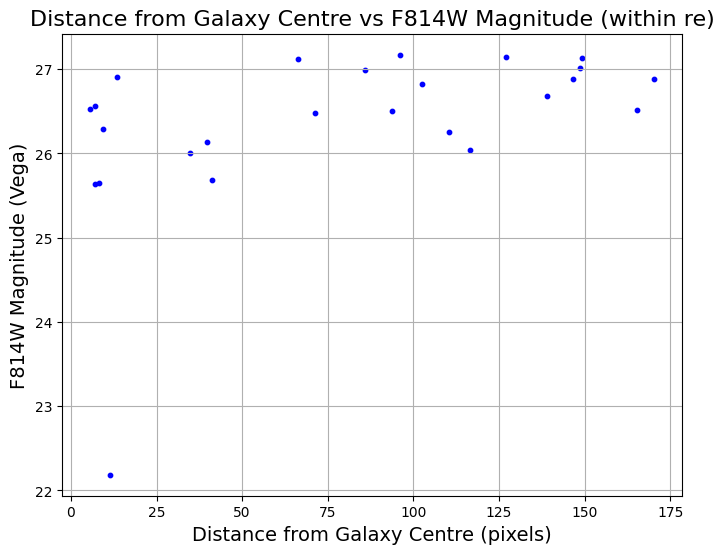

In [80]:
#plotting distance vs magnitude for f814w in re
plt.figure(figsize=(8,6))
plt.scatter(distgal_re0, f814mag_re0, color='blue', s=10)
plt.title('Distance from Galaxy Centre vs F814W Magnitude (within re)', fontsize=16)
plt.xlabel('Distance from Galaxy Centre (pixels)', fontsize=14) 
plt.ylabel('F814W Magnitude (Vega)', fontsize=14)
plt.grid()
plt.show()

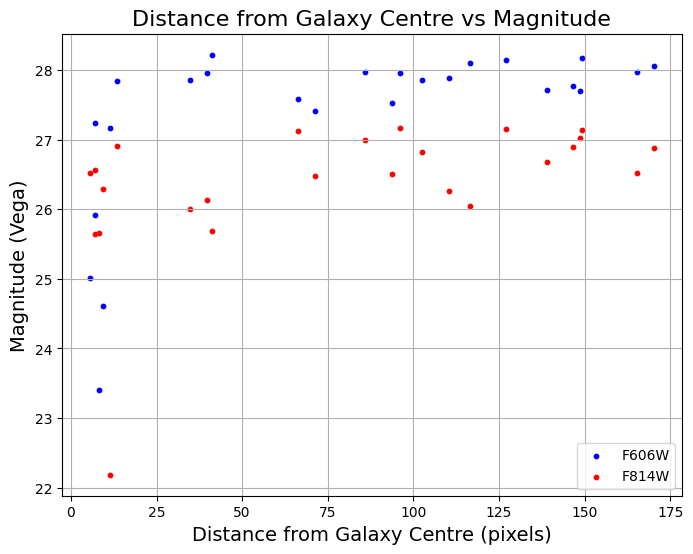

In [81]:
#plotting distance vs magnitude for the objects within re for both filters together
plt.figure(figsize=(8,6))
plt.scatter(distgal_re0, f606mag_re0, color='blue', s=10, label='F606W')
plt.scatter(distgal_re0, f814mag_re0, color='red', s=10, label='F814W')
plt.title('Distance from Galaxy Centre vs Magnitude', fontsize=16)
plt.xlabel('Distance from Galaxy Centre (pixels)', fontsize=14)
plt.ylabel('Magnitude (Vega)', fontsize=14)
plt.legend()
plt.grid()
plt.show()

In [116]:
# normalising the distance in terms of re
distgal_re0_n = distgal_re0/re_pixels0

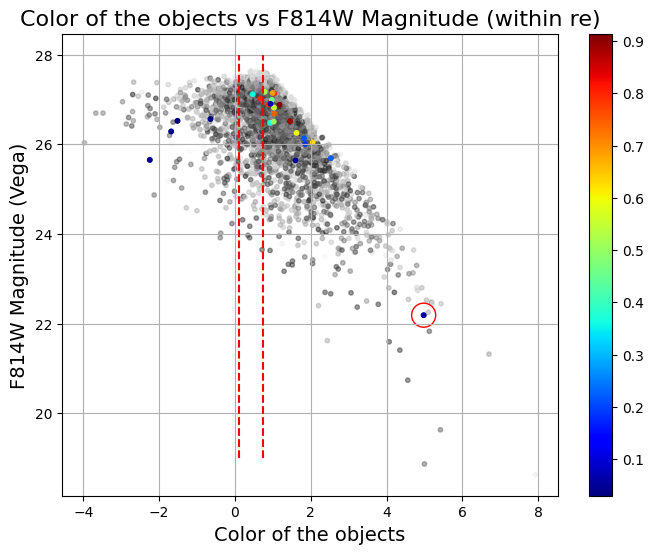

In [140]:
plt.figure(figsize=(8,6))
plt.scatter(colorfull0, f814mag0, c = distgal0,cmap = 'grey', s=10, alpha = 0.5)
plt.scatter(color0, f814mag_re0, c = distgal_re0_n,cmap = 'jet', s=10)
plt.colorbar()
plt.scatter(4.977, 22.186, ec = 'red', fc = 'none', s=300, alpha = 1, label='object with lowest mag within re')
plt.vlines(x = 0.1, ymin = 19, ymax = 28, color = 'red', linestyle = '--', label = 'Color = 0.1')
plt.vlines(x = 0.75, ymin = 19, ymax = 28, color = 'red', linestyle = '--', label = 'Color = 0.75')
plt.title('Color of the objects vs F814W Magnitude (within re)', fontsize=16)
plt.xlabel('Color of the objects', fontsize=14) 
plt.ylabel('F814W Magnitude (Vega)', fontsize=14)
plt.grid()
plt.show()

In [117]:
#Converting into absolute Mag
distgalpc0 = 11.1 * 1e6
absmag_re0 = f814mag_re0 - 5*np.log10(distgalpc0/10)

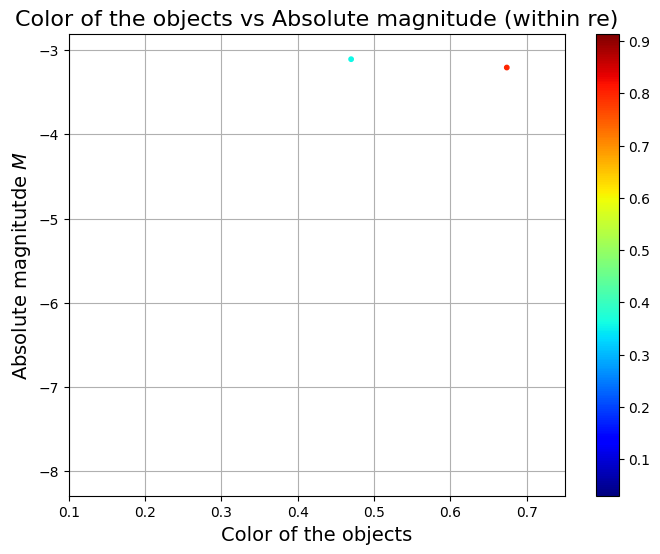

In [86]:
#plotting a color vs absolute magnitude for the objects within a re
plt.figure(figsize=(8,6))
plt.scatter(color0, absmag_re0, c = distgal_re0_n,cmap = 'jet', s=10)
plt.title('Color of the objects vs Absolute magnitude (within re)', fontsize=16)
plt.xlabel('Color of the objects', fontsize=14) 
plt.ylabel('Absolute magnitutde $M$', fontsize=14)
plt.xlim(0.1, 0.75)
plt.grid()
plt.colorbar()
plt.show()

In [118]:
#finding the mag of the object in 0.2 re
repixelsp20 = re_pixels0 * 0.2
print(repixelsp20)
f814mag_rep20 = f814mag0[distgal0 <= repixelsp20]

37.24000000000002


In [119]:
#Finding the mag difference of objects in 1 re then 0.2 re
max_mag_diff(f814mag_re0)# 1 re
max_mag_diff(f814mag_rep20)# 0.2 re

 The magnitude difference between the brightest and 2nd brightest object is -3.4549999999999983
 The magnitude difference between the brightest and 2nd brightest object is -3.4549999999999983


In [89]:
# adding concentration index to the catalog
newconcent0 = cut_cat0['newconcent']

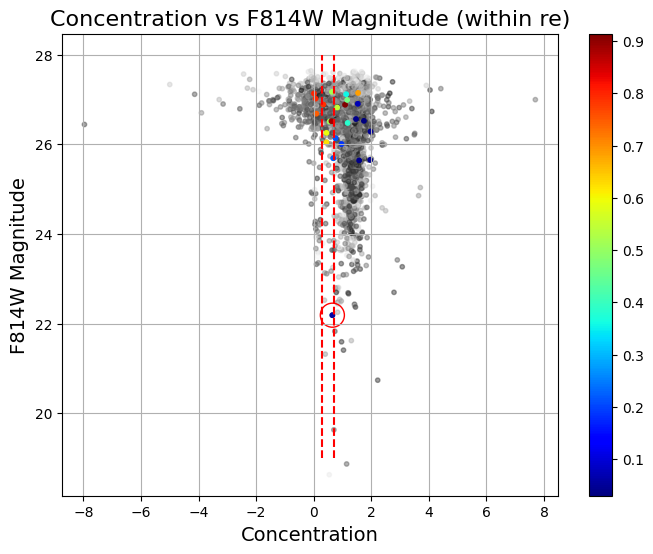

In [143]:
#Plotting the concentration vs Absolute magnitude graph withing 1 re
plt.figure(figsize=(8,6))
plt.scatter(newconcent0, f814mag0, c = distgal0,cmap = 'grey', s=10, alpha = 0.5)
plt.scatter(newconcent0[distgal0 <= re_pixels0], f814mag_re0, c = distgal_re0_n,cmap = 'jet', s=10)
plt.colorbar()
plt.scatter( 0.6483854626235106, 22.186, ec = 'red', fc = 'none', s=300, alpha = 1, label='object with lowest mag within re')
plt.vlines(x = 0.3, ymin = 19, ymax = 28, color = 'red', linestyle = '--', label = 'Concentration = 0.3')
plt.vlines(x = 0.7, ymin = 19, ymax = 28, color = 'red', linestyle = '--', label = 'Concentration = 0.7')
plt.title('Concentration vs F814W Magnitude (within re)', fontsize=16)
plt.xlabel('Concentration', fontsize=14) 
plt.ylabel('F814W Magnitude', fontsize=14)
plt.grid()
plt.show()

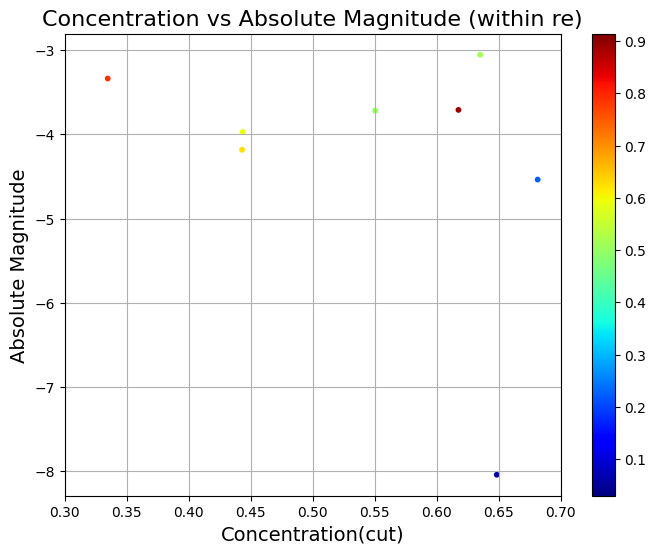

In [91]:
#Plotting the concentration(cut) vs Absolute magnitude graph withing 1 re
plt.figure(figsize=(8,6))
plt.scatter(newconcent0[distgal0 <= re_pixels0], absmag_re0, c = distgal_re0_n,cmap = 'jet', s=10)
plt.title('Concentration vs Absolute Magnitude (within re)', fontsize=16)
plt.xlabel('Concentration(cut)', fontsize=14) 
plt.ylabel('Absolute Magnitude', fontsize=14)
plt.xlim(0.3, 0.7)
plt.grid()
plt.colorbar()
plt.show()

In [128]:
# accessing the fits file to get the header and the wcs information
F814W0 = hdul0[1].data
F814W0header = hdul0[1].header



In [142]:
# Writing code to find the index of the brightest object in 1 re 
minmag0 = 50
for i in range(len(f814mag_re0)):
    if f814mag_re0[i] < minmag0:
        minmag0 = f814mag_re0[i]
        objdist0 = distgal_re0[i]

index0 = 0
for i in range(len(f814mag0)):
    if f814mag0[i] == minmag0:
        index0 = i

print(index0)
print(minmag0)
print(f814mag_re0)
print(distgal_re0)
print(color0)
print('concentration of the object with lowest mag within re:', list(newconcent0)[index0])

objxc0 = xcgal0[index0]
objyc0 = ycgal0[index0]

27
22.186
[22.186 25.652 26.287 26.524 26.565 25.641 25.69  26.477 26.043 26.255
 26.006 26.508 27.02  26.883 26.136 26.992 26.684 26.517 26.889 27.135
 27.119 26.821 27.172 26.904 27.147]
[ 11.30323301   8.25892843   9.32840279   5.57826958   6.88580207
   6.87203571  41.03887356  71.16830853 116.43847146 110.26764639
  34.81197668  93.77061608 148.54332638 170.19050041  39.78423494
  85.96882656 139.0579298  165.18633696 146.50450998 149.37463967
  66.26160957 102.40798702  96.22077267  13.54126996 127.11542049]
[ 4.977 -2.245 -1.681 -1.515 -0.644  1.6    2.528  0.927  2.051  1.624
  1.853  1.022  0.674  1.173  1.823  0.972  1.032  1.454  0.886  1.034
  0.47   1.029  0.786  0.936  0.995]
concentration of the object with lowest mag within re: 0.6483854626235106


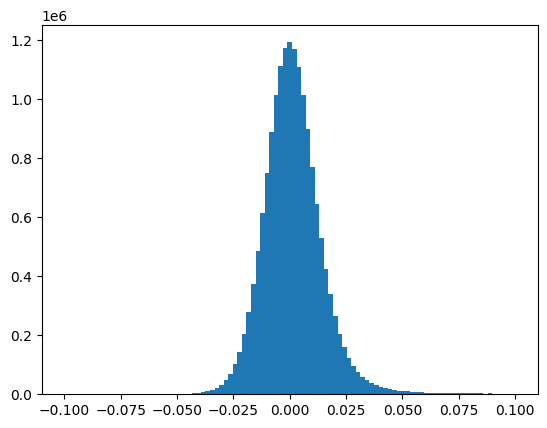

In [94]:
# Checking the distribution of pixel values in the F814W image
plt.hist(F814W0.ravel(),np.linspace(-0.1,0.1, 100))
plt.show()

# information on the target object
Absmag = -8.04061489, Appmag = 22.186, distance from the identified galactic center = 11.30323301 pixels, index of the object on the catalog is 27, concentration = 0.648385, color = 4.977

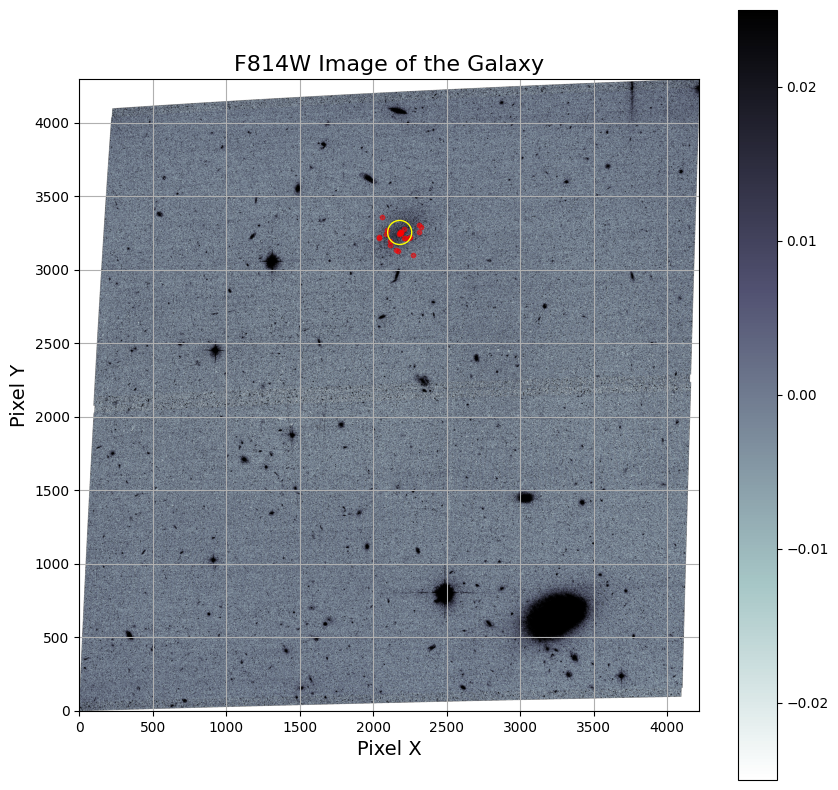

In [95]:
#Plotting the F814W image for the galaxy and overplot all the bright objects within re

fig0 = plt.figure(figsize=(10,10))
plt.imshow(F814W0, origin='lower', cmap='bone_r', vmin = -0.025, vmax = 0.025)
plt.colorbar()
plt.scatter(xcgal0[distgal0 <= re_pixels0], ycgal0[distgal0 <= re_pixels0], color='red', s=10, alpha = 0.5, label='Bright objects within re')
plt.scatter(objxc0, objyc0, ec = 'yellow', fc = 'none', s=300, alpha = 1, label='object with lowest mag within re')
plt.title('F814W Image of the Galaxy', fontsize=16)
plt.xlabel('Pixel X', fontsize=14)
plt.ylabel('Pixel Y', fontsize=14)
plt.grid()
plt.show()



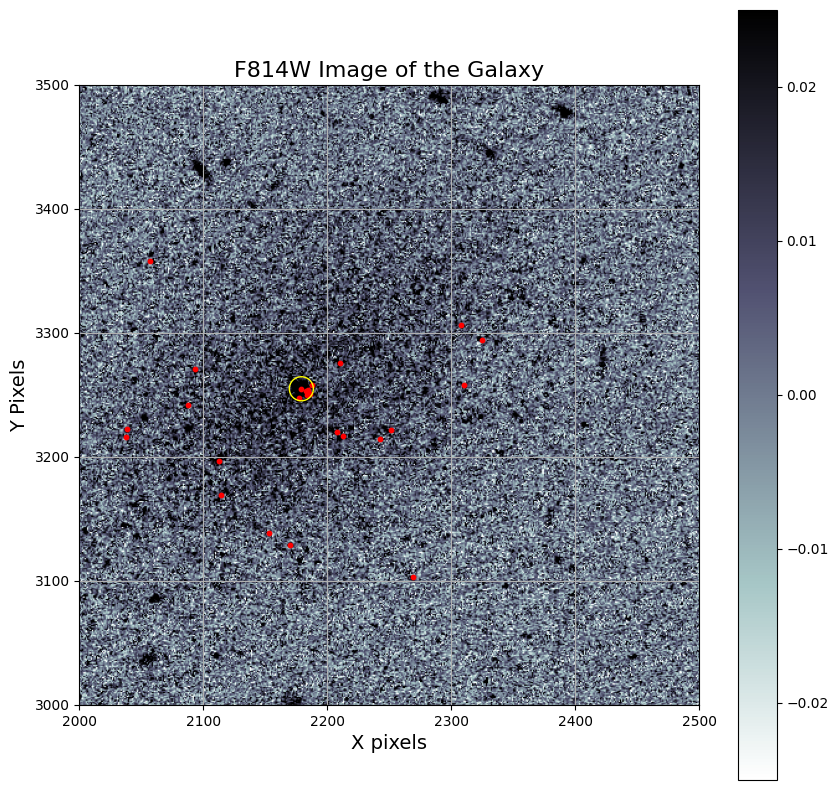

In [96]:
# zooming in for better visualization of the bright objects within re
fig0 = plt.figure(figsize=(10,10))
plt.imshow(F814W0, origin='lower', cmap='bone_r', vmin = -0.025, vmax = 0.025)
plt.colorbar()
plt.scatter(xcgal0[distgal0 <= re_pixels0], ycgal0[distgal0 <= re_pixels0], color='red', s=10, label='Bright objects within re')
plt.scatter(objxc0, objyc0, ec = 'yellow', fc = 'none', s=300, alpha = 1, label='object with lowest mag within re')
plt.title('F814W Image of the Galaxy', fontsize=16)
plt.xlabel('X pixels', fontsize=14)
plt.ylabel('Y Pixels', fontsize=14)
plt.xlim(2000, 2500)
plt.ylim(3000, 3500)
plt.grid()
plt.show()

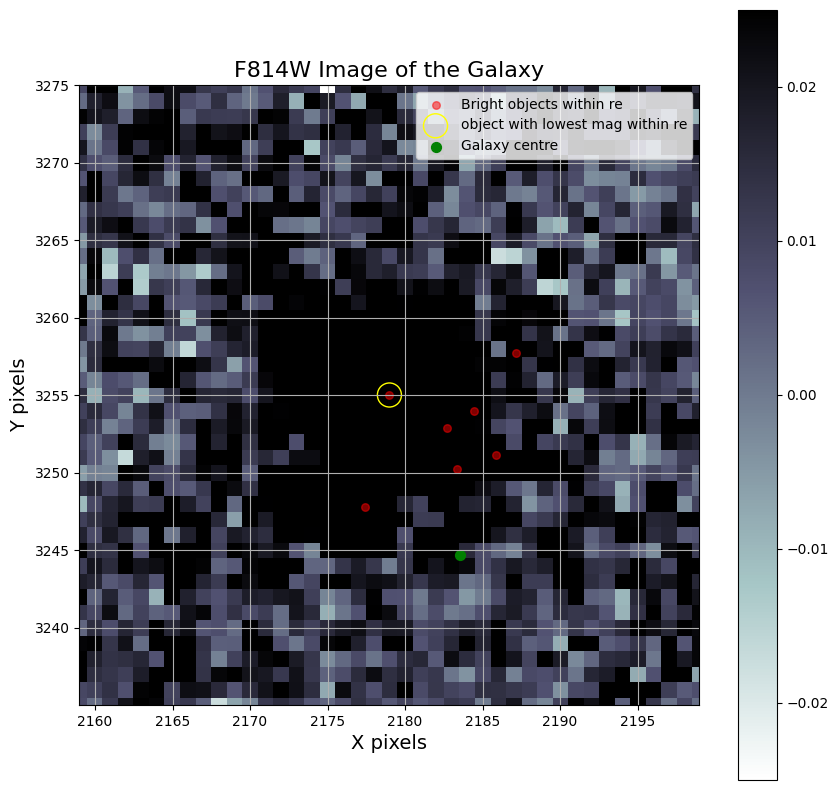

In [97]:
# zooming in even more to see the brightest and closest object to the centre of the galaxy
fig0 = plt.figure(figsize=(10,10))
plt.imshow(F814W0, origin='lower', cmap='bone_r', vmin = -0.025, vmax = 0.025)
plt.colorbar()
plt.scatter(xcgal0[distgal0 <= re_pixels0], ycgal0[distgal0 <= re_pixels0], color='red', s=30, alpha = 0.5, label='Bright objects within re')
plt.scatter(objxc0, objyc0, ec = 'yellow', fc = 'none', s=300, alpha = 1, label='object with lowest mag within re')
plt.scatter(galcenx0, galceny0, color='green', s=50, alpha = 1, label='Galaxy centre')
plt.title('F814W Image of the Galaxy', fontsize=16)
plt.xlabel('X pixels', fontsize=14)
plt.ylabel('Y pixels', fontsize=14)
plt.xlim(objxc0-20, objxc0+20)
plt.ylim(objyc0-20, objyc0+20)
plt.legend()
plt.grid()
plt.show()

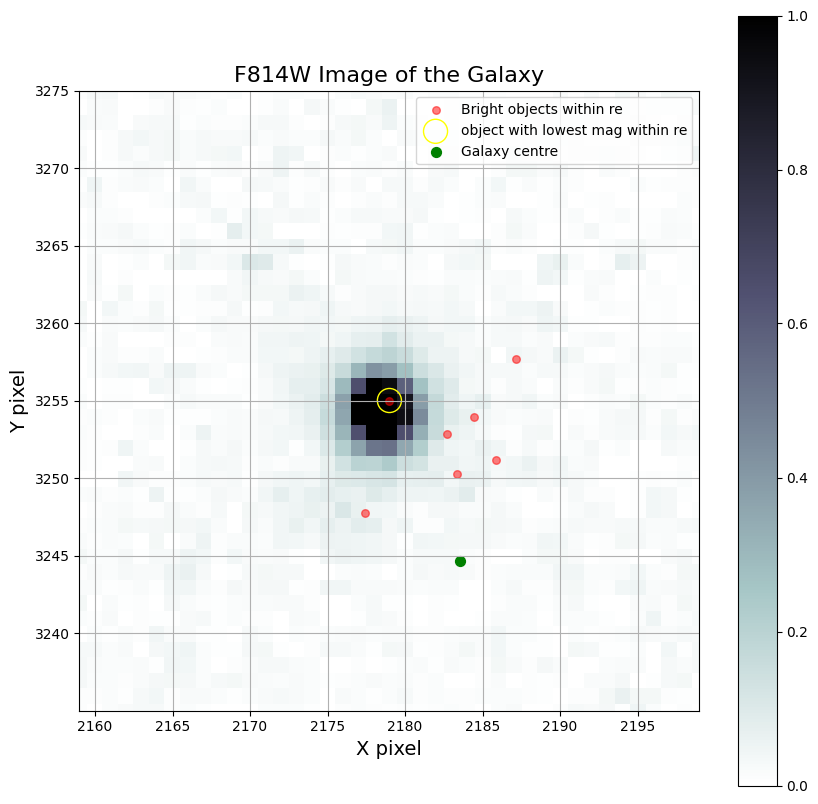

In [101]:
# trying to see how bright it is
fig0 = plt.figure(figsize=(10,10))
plt.imshow(F814W0, origin='lower', cmap='bone_r', vmin = 0, vmax = 1)
plt.colorbar()
plt.scatter(xcgal0[distgal0 <= re_pixels0], ycgal0[distgal0 <= re_pixels0], color='red', s=30, alpha = 0.5, label='Bright objects within re')
plt.scatter(objxc0, objyc0, ec = 'yellow', fc = 'none', s=300, alpha = 1, label='object with lowest mag within re')
plt.scatter(galcenx0, galceny0, color='green', s=50, alpha = 1, label='Galaxy centre')
plt.title('F814W Image of the Galaxy', fontsize=16)
plt.xlabel('X pixel', fontsize=14)
plt.ylabel('Y pixel', fontsize=14)
plt.xlim(objxc0-20, objxc0+20)
plt.ylim(objyc0-20, objyc0+20)
plt.legend()
plt.grid()
plt.show()

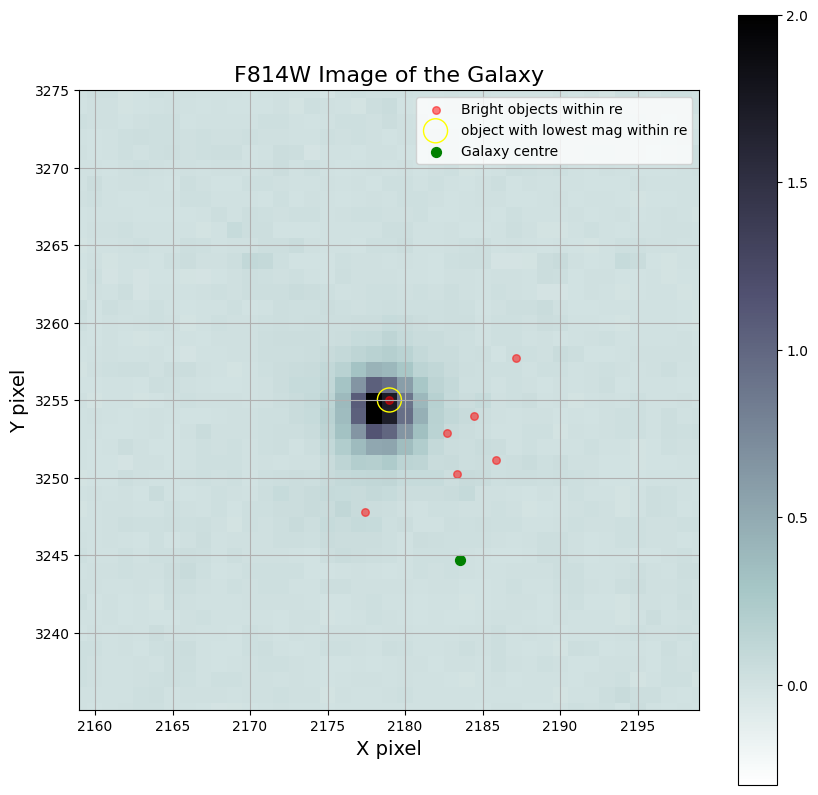

In [99]:
# trying to see how bright it is
fig0 = plt.figure(figsize=(10,10))
plt.imshow(F814W0, origin='lower', cmap='bone_r', vmin = -0.3, vmax = 2)
plt.colorbar()
plt.scatter(xcgal0[distgal0 <= re_pixels0], ycgal0[distgal0 <= re_pixels0], color='red', s=30, alpha = 0.5, label='Bright objects within re')
plt.scatter(objxc0, objyc0, ec = 'yellow', fc = 'none', s=300, alpha = 1, label='object with lowest mag within re')
plt.scatter(galcenx0, galceny0, color='green', s=50, alpha = 1, label='Galaxy centre')
plt.title('F814W Image of the Galaxy', fontsize=16)
plt.xlabel('X pixel', fontsize=14)
plt.ylabel('Y pixel', fontsize=14)
plt.xlim(objxc0-20, objxc0+20)
plt.ylim(objyc0-20, objyc0+20)
plt.legend()
plt.grid()
plt.show()

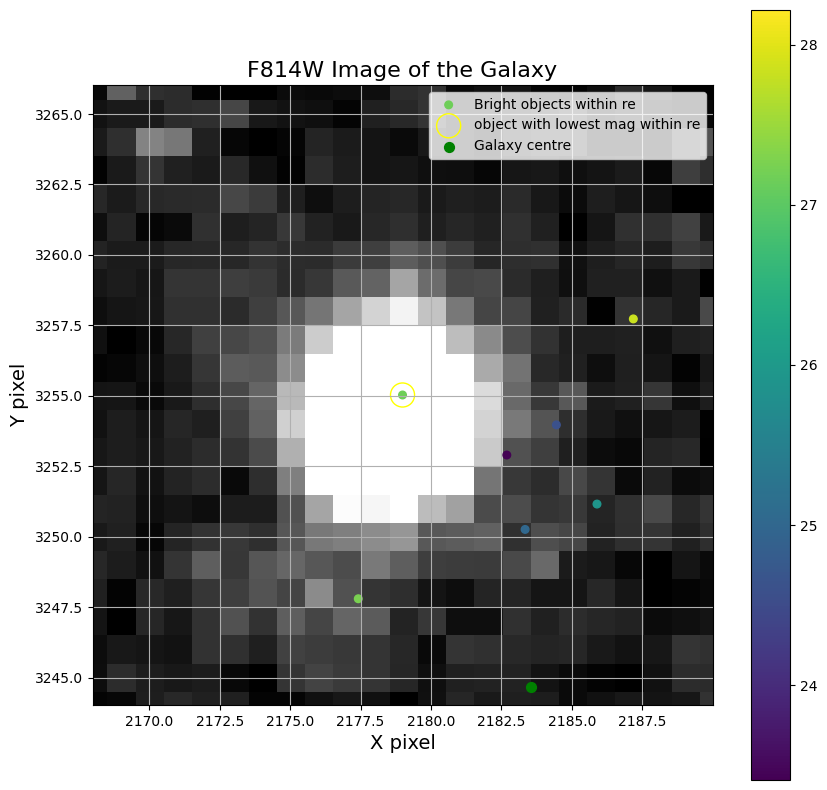

In [132]:
# Zooming in even more
lim = round(objdist0)
fig0 = plt.figure(figsize=(10,10))
plt.imshow(F814W0, origin='lower', cmap='grey', vmin = -0, vmax = 0.2)
plt.scatter(xcgal0[distgal0 <= re_pixels0], ycgal0[distgal0 <= re_pixels0], c = f606mag0[distgal0 <= re_pixels0], s=30, alpha = 1, label='Bright objects within re')
plt.colorbar()
plt.scatter(objxc0, objyc0, ec = 'yellow', fc = 'none', s=300, alpha = 1, label='object with lowest mag within re')
plt.scatter(galcenx0, galceny0, color='green', s=50, alpha = 1, label='Galaxy centre')
plt.title('F814W Image of the Galaxy', fontsize=16)
plt.xlabel('X pixel', fontsize=14)
plt.ylabel('Y pixel', fontsize=14)
plt.xlim(objxc0-lim, objxc0+lim)
plt.ylim(objyc0-lim, objyc0+lim)
plt.legend()
plt.grid()
plt.show()

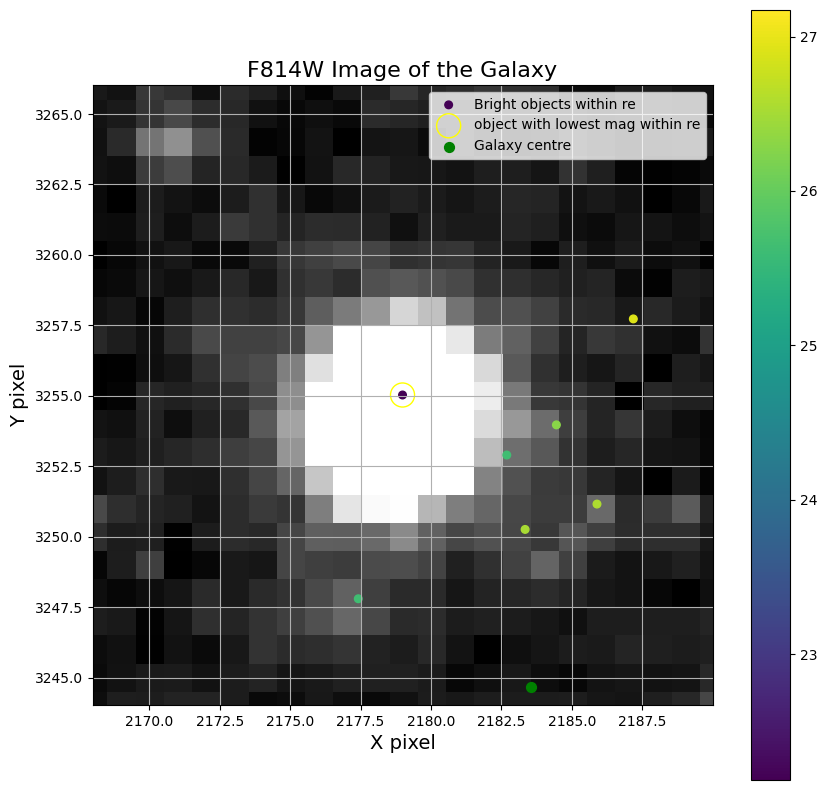

In [131]:
# Zooming in even more
lim = round(objdist0)
fig0 = plt.figure(figsize=(10,10))
plt.imshow(F606W0, origin='lower', cmap='grey', vmin = -0, vmax = 0.2)
plt.scatter(xcgal0[distgal0 <= re_pixels0], ycgal0[distgal0 <= re_pixels0], c = f814mag0[distgal0 <= re_pixels0], s=30, alpha = 1, label='Bright objects within re')
plt.colorbar()
plt.scatter(objxc0, objyc0, ec = 'yellow', fc = 'none', s=300, alpha = 1, label='object with lowest mag within re')
plt.scatter(galcenx0, galceny0, color='green', s=50, alpha = 1, label='Galaxy centre')
plt.title('F814W Image of the Galaxy', fontsize=16)
plt.xlabel('X pixel', fontsize=14)
plt.ylabel('Y pixel', fontsize=14)
plt.xlim(objxc0-lim, objxc0+lim)
plt.ylim(objyc0-lim, objyc0+lim)
plt.legend()
plt.grid()
plt.show()

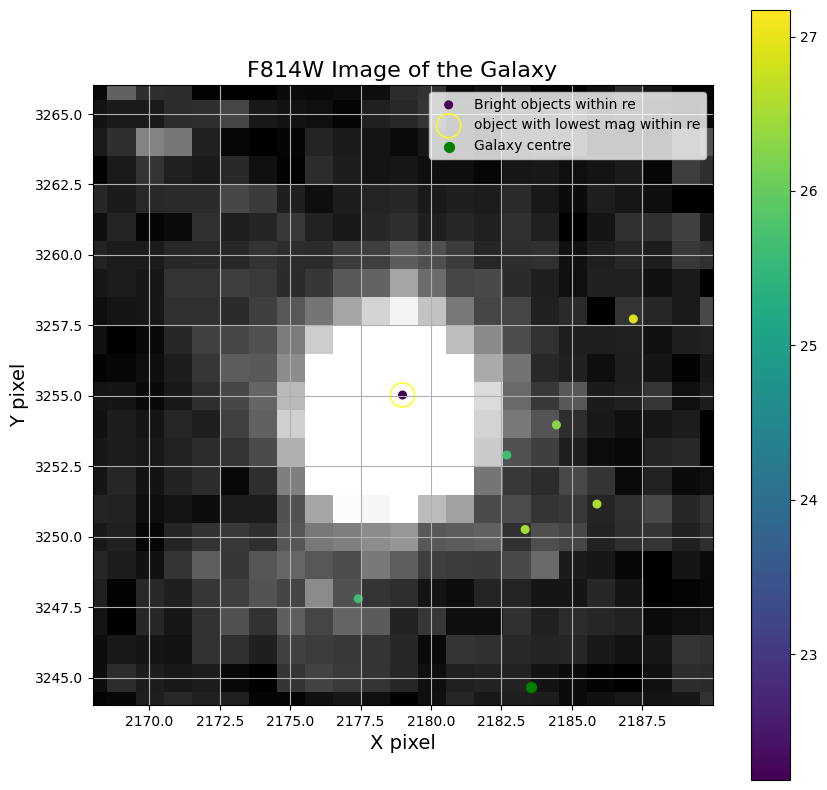

In [133]:
# Zooming in even more
lim = round(objdist0)
fig0 = plt.figure(figsize=(10,10))
plt.imshow(F814W0, origin='lower', cmap='grey', vmin = -0, vmax = 0.2)
plt.scatter(xcgal0[distgal0 <= re_pixels0], ycgal0[distgal0 <= re_pixels0], c = f814mag0[distgal0 <= re_pixels0], s=30, alpha = 1, label='Bright objects within re')
plt.colorbar()
plt.scatter(objxc0, objyc0, ec = 'yellow', fc = 'none', s=300, alpha = 1, label='object with lowest mag within re')
plt.scatter(galcenx0, galceny0, color='green', s=50, alpha = 1, label='Galaxy centre')
plt.title('F814W Image of the Galaxy', fontsize=16)
plt.xlabel('X pixel', fontsize=14)
plt.ylabel('Y pixel', fontsize=14)
plt.xlim(objxc0-lim, objxc0+lim)
plt.ylim(objyc0-lim, objyc0+lim)
plt.legend()
plt.grid()
plt.show()